In [198]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [199]:
# Load the Kaggle dataset from the raw folder
df = pd.read_csv("../data/raw/supply_chain_data.csv")

# Show first rows to confirm it loaded correctly
df.head()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632


In [200]:
# Display the number of rows and columns in the dataset
# This helps us understand how big the dataset is
print("Dataset Shape:", df.shape)

# Print all column names to understand what variables are available
print("\nColumn Names:")
print(df.columns)

# Display detailed information about the dataset:
# - data types of each column
# - number of non-null values
# This helps identify missing values and incorrect data types
print("\nDataset Info:")
df.info()

# Check how many missing values exist in each column
# Sorting helps quickly identify columns with most missing data
print("\nMissing values:")
df.isna().sum().sort_values(ascending=False)

Dataset Shape: (100, 24)

Column Names:
Index(['Product type', 'SKU', 'Price', 'Availability',
       'Number of products sold', 'Revenue generated', 'Customer demographics',
       'Stock levels', 'Lead times', 'Order quantities', 'Shipping times',
       'Shipping carriers', 'Shipping costs', 'Supplier name', 'Location',
       'Lead time', 'Production volumes', 'Manufacturing lead time',
       'Manufacturing costs', 'Inspection results', 'Defect rates',
       'Transportation modes', 'Routes', 'Costs'],
      dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Product type             100 non-null    str    
 1   SKU                      100 non-null    str    
 2   Price                    100 non-null    float64
 3   Availability             100 non-null    int64  
 4   Number of products sold  100 no

Product type               0
SKU                        0
Routes                     0
Transportation modes       0
Defect rates               0
Inspection results         0
Manufacturing costs        0
Manufacturing lead time    0
Production volumes         0
Lead time                  0
Location                   0
Supplier name              0
Shipping costs             0
Shipping carriers          0
Shipping times             0
Order quantities           0
Lead times                 0
Stock levels               0
Customer demographics      0
Revenue generated          0
Number of products sold    0
Availability               0
Price                      0
Costs                      0
dtype: int64

In [201]:
# Display first 10 rows to better understand the dataset structure
display(df.head(10))

# Display last 5 rows to see how data ends
display(df.tail())

# Show statistical summary of numeric columns
df.describe()

,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
0,haircare,SKU0,69.808006,55,802,8661.996792,Non-binary,58,7,96,...,Mumbai,29,215,29,46.279879,Pending,0.226410,Road,Route B,187.752075
1,skincare,SKU1,14.843523,95,736,7460.900065,Female,53,30,37,...,Mumbai,23,517,30,33.616769,Pending,4.854068,Road,Route B,503.065579
2,haircare,SKU2,11.319683,34,8,9577.749626,Unknown,1,10,88,...,Mumbai,12,971,27,30.688019,Pending,4.580593,Air,Route C,141.920282
3,skincare,SKU3,61.163343,68,83,7766.836426,Non-binary,23,13,59,...,Kolkata,24,937,18,35.624741,Fail,4.746649,Rail,Route A,254.776159
4,skincare,SKU4,4.805496,26,871,2686.505152,Non-binary,5,3,56,...,Delhi,5,414,3,92.065161,Fail,3.145580,Air,Route A,923.440632
5,haircare,SKU5,1.699976,87,147,2828.348746,Non-binary,90,27,66,...,Bangalore,10,104,17,56.766476,Fail,2.779194,Road,Route A,235.461237
6,skincare,SKU6,4.078333,48,65,7823.476560,Male,11,15,58,...,Kolkata,14,314,24,1.085069,Pending,1.000911,Sea,Route A,134.369097
7,cosmetics,SKU7,42.958384,59,426,8496.103813,Female,93,17,11,...,Bangalore,22,564,1,99.466109,Fail,0.398177,Road,Route C,802.056312
8,cosmetics,SKU8,68.717597,78,150,7517.363211,Female,5,10,15,...,Mumbai,13,769,8,11.423027,Pending,2.709863,Sea,Route B,505.557134
9,skincare,SKU9,64.015733,35,980,4971.145988,Unknown,14,27,83,...,Chennai,29,963,23,47.957602,Pending,3.844614,Rail,Route B,995.929461


,Product type,SKU,Price,Availability,Number of products sold,Revenue generated,Customer demographics,Stock levels,Lead times,Order quantities,...,Location,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Inspection results,Defect rates,Transportation modes,Routes,Costs
95,haircare,SKU95,77.903927,65,672,7386.363944,Unknown,15,14,26,...,Mumbai,18,450,26,58.890686,Pending,1.210882,Air,Route A,778.864241
96,cosmetics,SKU96,24.423131,29,324,7698.424766,Non-binary,67,2,32,...,Mumbai,28,648,28,17.803756,Pending,3.872048,Road,Route A,188.742141
97,haircare,SKU97,3.526111,56,62,4370.916580,Male,46,19,4,...,Mumbai,10,535,13,65.765156,Fail,3.376238,Road,Route A,540.132423
98,skincare,SKU98,19.754605,43,913,8525.952560,Female,53,1,27,...,Chennai,28,581,9,5.604691,Pending,2.908122,Rail,Route A,882.198864
99,haircare,SKU99,68.517833,17,627,9185.185829,Unknown,55,8,59,...,Chennai,29,921,2,38.072899,Fail,0.346027,Rail,Route B,210.743009


,Price,Availability,Number of products sold,Revenue generated,Stock levels,Lead times,Order quantities,Shipping times,Shipping costs,Lead time,Production volumes,Manufacturing lead time,Manufacturing costs,Defect rates,Costs
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,49.462461,48.400000,460.990000,5776.048187,47.770000,15.960000,49.220000,5.750000,5.548149,17.080000,567.840000,14.77000,47.266693,2.277158,529.245782
std,31.168193,30.743317,303.780074,2732.841744,31.369372,8.785801,26.784429,2.724283,2.651376,8.846251,263.046861,8.91243,28.982841,1.461366,258.301696
min,1.699976,1.000000,8.000000,1061.618523,0.000000,1.000000,1.000000,1.000000,1.013487,1.000000,104.000000,1.00000,1.085069,0.018608,103.916248
25%,19.597823,22.750000,184.250000,2812.847151,16.750000,8.000000,26.000000,3.750000,3.540248,10.000000,352.000000,7.00000,22.983299,1.009650,318.778455
50%,51.239831,43.500000,392.500000,6006.352023,47.500000,17.000000,52.000000,6.000000,5.320534,18.000000,568.500000,14.00000,45.905622,2.141863,520.430444
75%,77.198228,75.000000,704.250000,8253.976921,73.000000,24.000000,71.250000,8.000000,7.601695,25.000000,797.000000,23.00000,68.621026,3.563995,763.078231
max,99.171329,100.000000,996.000000,9866.465458,100.000000,30.000000,96.000000,10.000000,9.929816,30.000000,985.000000,30.00000,99.466109,4.939255,997.413450


In [202]:
# Standardize column names: remove spaces and make lowercase
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# Check updated column names
df.columns

Index(['product_type', 'sku', 'price', 'availability',
       'number_of_products_sold', 'revenue_generated', 'customer_demographics',
       'stock_levels', 'lead_times', 'order_quantities', 'shipping_times',
       'shipping_carriers', 'shipping_costs', 'supplier_name', 'location',
       'lead_time', 'production_volumes', 'manufacturing_lead_time',
       'manufacturing_costs', 'inspection_results', 'defect_rates',
       'transportation_modes', 'routes', 'costs'],
      dtype='str')

In [203]:
# Create spend column (core procurement metric)
# Spend = unit cost * order quantity

df["spend"] = df["costs"] * df["order_quantities"]

# Preview new column
df[["supplier_name", "product_type", "order_quantities", "costs", "spend"]].head()

,supplier_name,product_type,order_quantities,costs,spend
0,Supplier 3,haircare,96,187.752075,18024.199244
1,Supplier 3,skincare,37,503.065579,18613.426429
2,Supplier 1,haircare,88,141.920282,12488.984796
3,Supplier 5,skincare,59,254.776159,15031.793394
4,Supplier 1,skincare,56,923.440632,51712.675376


In [204]:
# Check missing values percentage per column
missing_percent = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": missing_percent
}).sort_values("missing_percent", ascending=False)

missing_summary

,missing_count,missing_percent
product_type,0,0.0
supplier_name,0,0.0
costs,0,0.0
routes,0,0.0
transportation_modes,0,0.0
defect_rates,0,0.0
inspection_results,0,0.0
manufacturing_costs,0,0.0
manufacturing_lead_time,0,0.0
production_volumes,0,0.0


In [205]:
# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("Duplicate rows:", duplicate_count)

Duplicate rows: 0


In [206]:
df.dtypes

product_type                   str
sku                            str
price                      float64
availability                 int64
number_of_products_sold      int64
revenue_generated          float64
customer_demographics          str
stock_levels                 int64
lead_times                   int64
order_quantities             int64
shipping_times               int64
shipping_carriers              str
shipping_costs             float64
supplier_name                  str
location                       str
lead_time                    int64
production_volumes           int64
manufacturing_lead_time      int64
manufacturing_costs        float64
inspection_results             str
defect_rates               float64
transportation_modes           str
routes                         str
costs                      float64
spend                      float64
dtype: object

In [207]:
# Compare the two lead time columns to see if they contain the same values
(df["lead_times"] == df["lead_time"]).value_counts()

False    99
True      1
Name: count, dtype: int64

In [208]:
# Total lead time from supplier to delivery
df["total_lead_time"] = (
    df["lead_time"] + 
    df["manufacturing_lead_time"] + 
    df["shipping_times"]
)

df[["lead_time","manufacturing_lead_time","shipping_times","total_lead_time"]].head()

,lead_time,manufacturing_lead_time,shipping_times,total_lead_time
0,29,29,4,62
1,23,30,2,55
2,12,27,2,41
3,24,18,6,48
4,5,3,8,16


In [209]:
# Create a flag for high defect risk
# Suppliers with defect rate > 3% are considered risky

df["high_defect_flag"] = np.where(df["defect_rates"] > 0.03, 1, 0)

# Check distribution
df["high_defect_flag"].value_counts()

high_defect_flag
1    98
0     2
Name: count, dtype: int64

In [210]:
# Calculate total procurement cost per order
df["total_procurement_cost"] = (
    df["manufacturing_costs"] + df["shipping_costs"]
)

df[["manufacturing_costs","shipping_costs","total_procurement_cost"]].head()

,manufacturing_costs,shipping_costs,total_procurement_cost
0,46.279879,2.956572,49.236451
1,33.616769,9.716575,43.333344
2,30.688019,8.054479,38.742499
3,35.624741,1.729569,37.354310
4,92.065161,3.890548,95.955709


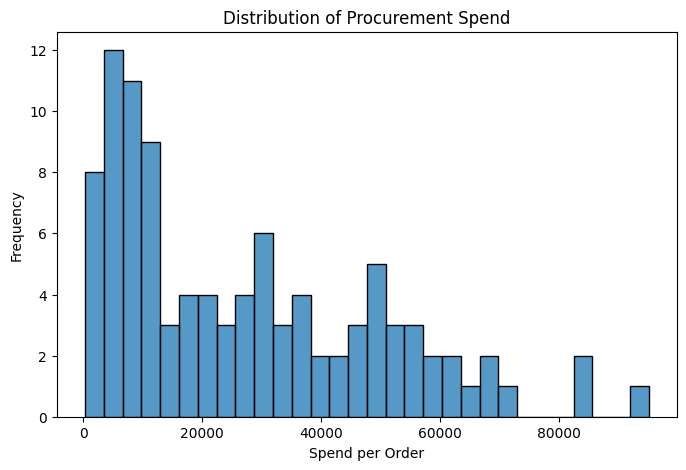

In [211]:
# Analyze how procurement spend is distributed across orders
# This helps identify whether most orders are small or if a few large orders dominate

plt.figure(figsize=(8,5))

sns.histplot(df["spend"], bins=30)

plt.title("Distribution of Procurement Spend")
plt.xlabel("Spend per Order")
plt.ylabel("Frequency")

plt.show()

In [212]:
# Calculate total procurement spend for each supplier
# This helps identify which suppliers receive the highest share of spending

spend_by_supplier = (
    df.groupby("supplier_name")["spend"]
      .sum()
      .sort_values(ascending=False)
)

# Display top 10 suppliers by total spend
spend_by_supplier.head(10)

supplier_name
Supplier 1    888106.716663
Supplier 5    534520.807370
Supplier 2    517436.164241
Supplier 4    450648.112668
Supplier 3    328828.272868
Name: spend, dtype: float64

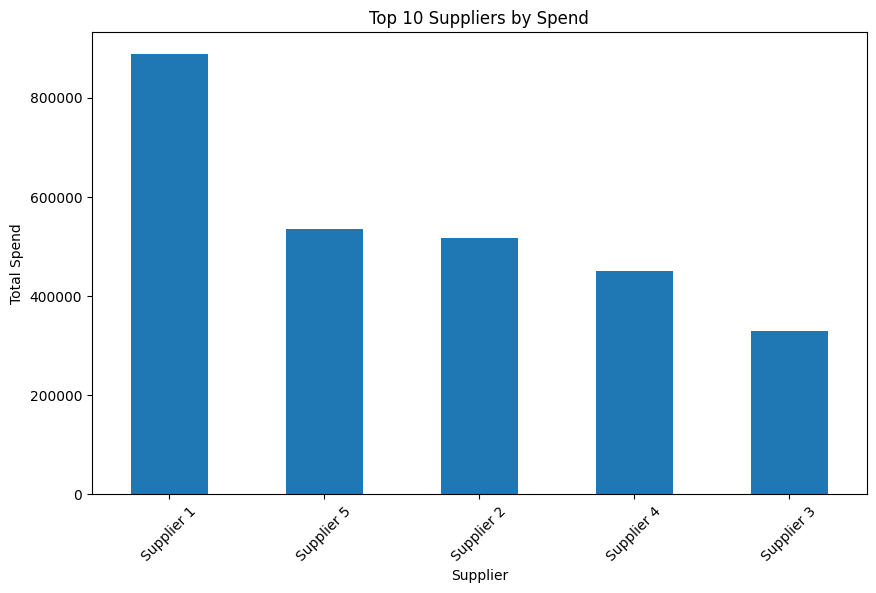

In [213]:
# Create a bar chart to visualize supplier spend concentration
# This helps quickly see if a few suppliers dominate procurement spending

plt.figure(figsize=(10,6))

spend_by_supplier.head(10).plot(kind="bar")

plt.title("Top 10 Suppliers by Spend")
plt.xlabel("Supplier")
plt.ylabel("Total Spend")
plt.xticks(rotation=45)

plt.show()

In [214]:
# Calculate average price per product type
# This gives us a benchmark price for comparison

avg_price_product = (
    df.groupby("product_type")["costs"]
      .mean()
      .sort_values(ascending=False)
)

avg_price_product.head()

product_type
skincare     555.732952
cosmetics    514.092203
haircare     509.672437
Name: costs, dtype: float64

In [215]:
# Calculate average price charged by each supplier for each product
supplier_product_price = (
    df.groupby(["supplier_name", "product_type"])["costs"]
      .mean()
      .reset_index()
)

# Add benchmark price for each product
supplier_product_price = supplier_product_price.merge(
    avg_price_product.rename("benchmark_price"),
    on="product_type"
)

supplier_product_price.head()

,supplier_name,product_type,costs,benchmark_price
0,Supplier 1,cosmetics,517.249440,514.092203
1,Supplier 1,haircare,534.960459,509.672437
2,Supplier 1,skincare,615.028825,555.732952
3,Supplier 2,cosmetics,430.484256,514.092203
4,Supplier 2,haircare,554.709649,509.672437


In [216]:
# Calculate price premium percentage vs benchmark
supplier_product_price["price_premium_%"] = (
    (supplier_product_price["costs"] - supplier_product_price["benchmark_price"])
    / supplier_product_price["benchmark_price"]
) * 100

supplier_product_price.sort_values("price_premium_%", ascending=False).head(10)

,supplier_name,product_type,costs,benchmark_price,price_premium_%
9,Supplier 4,cosmetics,792.716140,514.092203,54.197270
2,Supplier 1,skincare,615.028825,555.732952,10.669850
4,Supplier 2,haircare,554.709649,509.672437,8.836501
13,Supplier 5,haircare,550.018912,509.672437,7.916158
1,Supplier 1,haircare,534.960459,509.672437,4.961622
14,Supplier 5,skincare,582.239825,555.732952,4.769714
0,Supplier 1,cosmetics,517.249440,514.092203,0.614138
5,Supplier 2,skincare,554.022604,555.732952,-0.307764
8,Supplier 3,skincare,529.714400,555.732952,-4.681844
10,Supplier 4,haircare,483.105865,509.672437,-5.212480


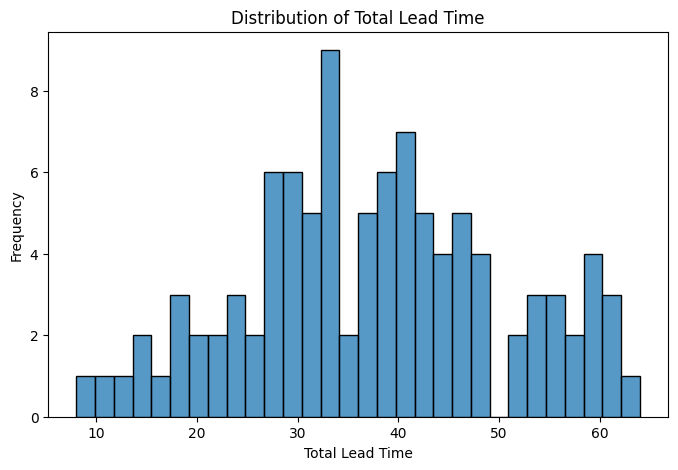

In [217]:
# Analyze distribution of total lead time
# This shows how long suppliers typically take to deliver

plt.figure(figsize=(8,5))

sns.histplot(df["total_lead_time"], bins=30)

plt.title("Distribution of Total Lead Time")
plt.xlabel("Total Lead Time")
plt.ylabel("Frequency")

plt.show()

In [218]:
# Calculate average delivery time per supplier
# Helps identify slow and fast suppliers

leadtime_supplier = (
    df.groupby("supplier_name")["total_lead_time"]
      .mean()
      .sort_values(ascending=False)
)

leadtime_supplier.head(10)

supplier_name
Supplier 5    40.611111
Supplier 3    40.266667
Supplier 2    39.636364
Supplier 4    36.111111
Supplier 1    33.444444
Name: total_lead_time, dtype: float64

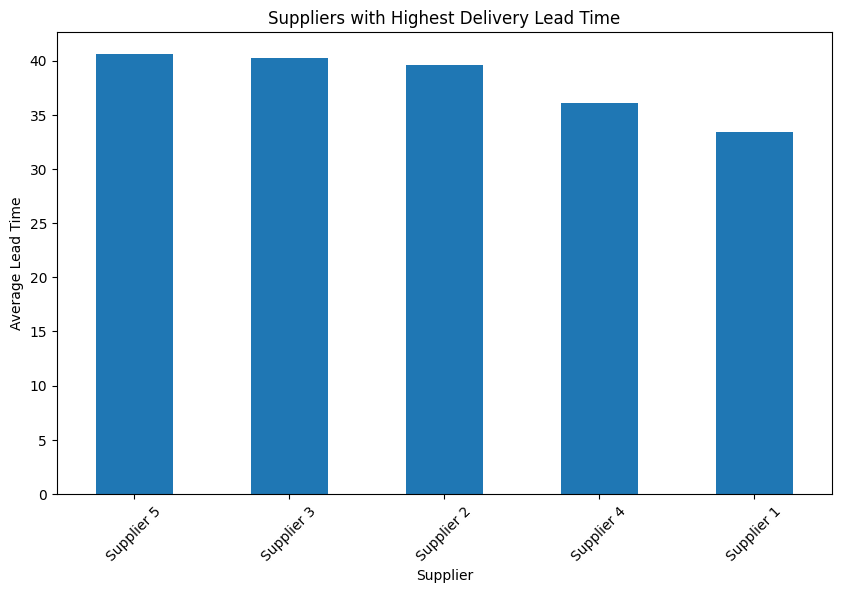

In [219]:
# Visualize suppliers with highest lead times (slow suppliers)

plt.figure(figsize=(10,6))

leadtime_supplier.head(10).plot(kind="bar")

plt.title("Suppliers with Highest Delivery Lead Time")
plt.xlabel("Supplier")
plt.ylabel("Average Lead Time")
plt.xticks(rotation=45)

plt.show()

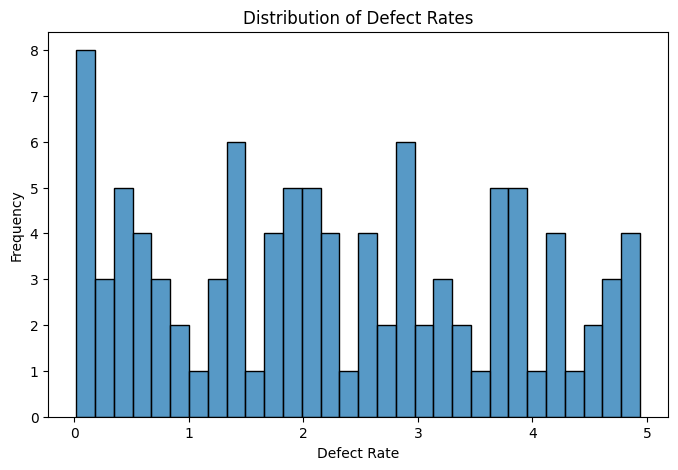

In [220]:
# Analyze distribution of defect rates across orders
plt.figure(figsize=(8,5))

sns.histplot(df["defect_rates"], bins=30)

plt.title("Distribution of Defect Rates")
plt.xlabel("Defect Rate")
plt.ylabel("Frequency")

plt.show()

In [221]:
# Calculate average defect rate for each supplier
defect_supplier = (
    df.groupby("supplier_name")["defect_rates"]
      .mean()
      .sort_values(ascending=False)
)

defect_supplier

supplier_name
Supplier 5    2.665408
Supplier 3    2.465786
Supplier 2    2.362750
Supplier 4    2.337397
Supplier 1    1.803630
Name: defect_rates, dtype: float64

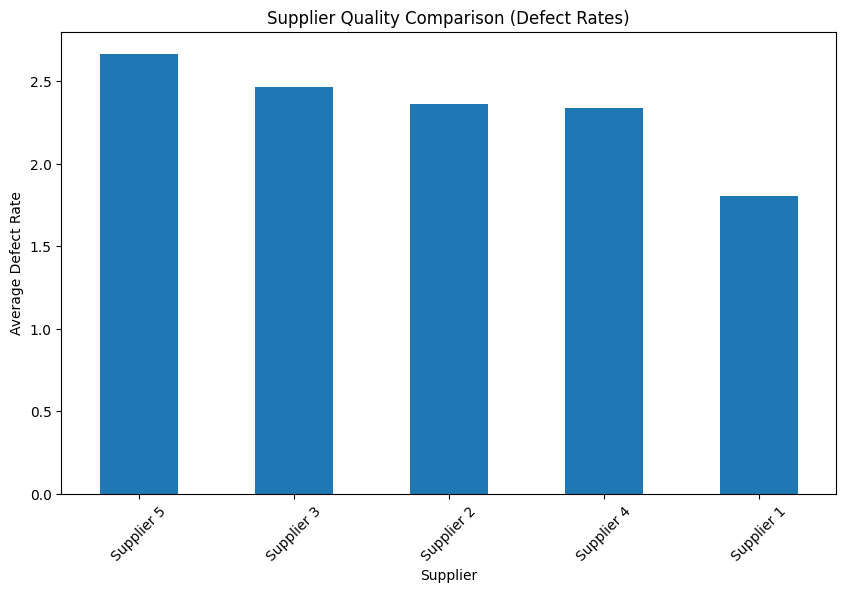

In [222]:
# Visualize suppliers with highest defect rates
plt.figure(figsize=(10,6))

defect_supplier.plot(kind="bar")

plt.title("Supplier Quality Comparison (Defect Rates)")
plt.xlabel("Supplier")
plt.ylabel("Average Defect Rate")
plt.xticks(rotation=45)

plt.show()

In [223]:
# Calculate total spend per supplier
supplier_spend = df.groupby("supplier_name")["spend"].sum()

In [224]:
# Average procurement cost per supplier
supplier_cost = df.groupby("supplier_name")["total_procurement_cost"].mean()

In [225]:
# Average total lead time per supplier
supplier_leadtime = df.groupby("supplier_name")["total_lead_time"].mean()

In [226]:
# Average defect rate per supplier
supplier_defect = df.groupby("supplier_name")["defect_rates"].mean()

In [227]:
# Number of orders handled by supplier
supplier_orders = df.groupby("supplier_name")["sku"].count()

In [228]:
# Combine all supplier KPIs into one table
supplier_kpi = pd.DataFrame({
    "total_spend": supplier_spend,
    "avg_procurement_cost": supplier_cost,
    "avg_lead_time": supplier_leadtime,
    "avg_defect_rate": supplier_defect,
    "order_volume": supplier_orders
})

supplier_kpi

,total_spend,avg_procurement_cost,avg_lead_time,avg_defect_rate,order_volume
supplier_name,,,,,
Supplier 1,888106.716663,50.766329,33.444444,1.803630,27
Supplier 2,517436.164241,47.361692,39.636364,2.362750,22
Supplier 3,328828.272868,48.422892,40.266667,2.465786,15
Supplier 4,450648.112668,68.469300,36.111111,2.337397,18
Supplier 5,534520.807370,50.558075,40.611111,2.665408,18


In [229]:
# Normalize KPI columns using Min-Max scaling
# This converts values to range 0–1

supplier_kpi_norm = (supplier_kpi - supplier_kpi.min()) / (supplier_kpi.max() - supplier_kpi.min())

supplier_kpi_norm

,total_spend,avg_procurement_cost,avg_lead_time,avg_defect_rate,order_volume
supplier_name,,,,,
Supplier 1,1.000000,0.161299,0.000000,0.000000,1.000000
Supplier 2,0.337234,0.000000,0.863989,0.648798,0.583333
Supplier 3,0.000000,0.050276,0.951938,0.768360,0.000000
Supplier 4,0.217816,1.000000,0.372093,0.619379,0.250000
Supplier 5,0.367782,0.151433,1.000000,1.000000,0.250000


In [230]:
# Reverse metrics where LOWER value means better performance

# Lower procurement cost is better → invert
supplier_kpi_norm["avg_procurement_cost"] = 1 - supplier_kpi_norm["avg_procurement_cost"]

# Lower delivery lead time is better → invert
supplier_kpi_norm["avg_lead_time"] = 1 - supplier_kpi_norm["avg_lead_time"]

# Lower defect rate is better → invert
supplier_kpi_norm["avg_defect_rate"] = 1 - supplier_kpi_norm["avg_defect_rate"]

In [231]:
# Define weights
weights = {
    "total_spend": 0.30,
    "avg_procurement_cost": 0.25,
    "avg_lead_time": 0.25,
    "avg_defect_rate": 0.20
}

# Calculate weighted supplier score
supplier_kpi_norm["supplier_score"] = (
    supplier_kpi_norm["total_spend"] * weights["total_spend"] +
    supplier_kpi_norm["avg_procurement_cost"] * weights["avg_procurement_cost"] +
    supplier_kpi_norm["avg_lead_time"] * weights["avg_lead_time"] +
    supplier_kpi_norm["avg_defect_rate"] * weights["avg_defect_rate"]
)

supplier_kpi_norm.sort_values("supplier_score", ascending=False)

,total_spend,avg_procurement_cost,avg_lead_time,avg_defect_rate,order_volume,supplier_score
supplier_name,,,,,,
Supplier 1,1.000000,0.838701,1.000000,1.000000,1.000000,0.959675
Supplier 2,0.337234,1.000000,0.136011,0.351202,0.583333,0.455413
Supplier 5,0.367782,0.848567,0.000000,0.000000,0.250000,0.322476
Supplier 4,0.217816,0.000000,0.627907,0.380621,0.250000,0.298446
Supplier 3,0.000000,0.949724,0.048062,0.231640,0.000000,0.295775


In [232]:
# Re-segment suppliers using percentiles instead of fixed thresholds
# This creates balanced categories based on relative performance

supplier_kpi_norm["supplier_category"] = pd.qcut(
    supplier_kpi_norm["supplier_score"],
    q=3,
    labels=[
        "High Risk - Replace",
        "Competitive - Negotiate",
        "Strategic Partner"
    ]
)

# View suppliers ranked by score
supplier_kpi_norm.sort_values("supplier_score", ascending=False)

,total_spend,avg_procurement_cost,avg_lead_time,avg_defect_rate,order_volume,supplier_score,supplier_category
supplier_name,,,,,,,
Supplier 1,1.000000,0.838701,1.000000,1.000000,1.000000,0.959675,Strategic Partner
Supplier 2,0.337234,1.000000,0.136011,0.351202,0.583333,0.455413,Strategic Partner
Supplier 5,0.367782,0.848567,0.000000,0.000000,0.250000,0.322476,Competitive - Negotiate
Supplier 4,0.217816,0.000000,0.627907,0.380621,0.250000,0.298446,High Risk - Replace
Supplier 3,0.000000,0.949724,0.048062,0.231640,0.000000,0.295775,High Risk - Replace


In [233]:
supplier_kpi_norm["supplier_category"].value_counts()

supplier_category
High Risk - Replace        2
Strategic Partner          2
Competitive - Negotiate    1
Name: count, dtype: int64

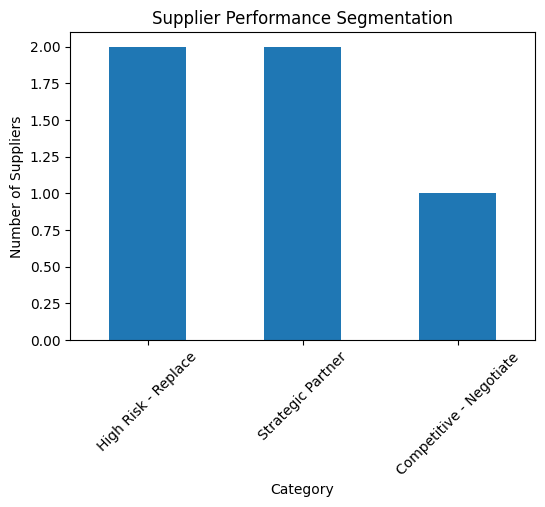

In [234]:
plt.figure(figsize=(6,4))

supplier_kpi_norm["supplier_category"].value_counts().plot(kind="bar")

plt.title("Supplier Performance Segmentation")
plt.xlabel("Category")
plt.ylabel("Number of Suppliers")
plt.xticks(rotation=45)

plt.show()

In [235]:
# Create final scorecard table (clean view for business)
final_scorecard = supplier_kpi.copy()

# Add score and category from normalized table
final_scorecard["supplier_score"] = supplier_kpi_norm["supplier_score"]
final_scorecard["supplier_category"] = supplier_kpi_norm["supplier_category"]

# Sort from best to worst supplier
final_scorecard = final_scorecard.sort_values("supplier_score", ascending=False)

final_scorecard

,total_spend,avg_procurement_cost,avg_lead_time,avg_defect_rate,order_volume,supplier_score,supplier_category
supplier_name,,,,,,,
Supplier 1,888106.716663,50.766329,33.444444,1.803630,27,0.959675,Strategic Partner
Supplier 2,517436.164241,47.361692,39.636364,2.362750,22,0.455413,Strategic Partner
Supplier 5,534520.807370,50.558075,40.611111,2.665408,18,0.322476,Competitive - Negotiate
Supplier 4,450648.112668,68.469300,36.111111,2.337397,18,0.298446,High Risk - Replace
Supplier 3,328828.272868,48.422892,40.266667,2.465786,15,0.295775,High Risk - Replace


In [236]:
# Suppliers to negotiate with (middle category)
negotiation_targets = final_scorecard[final_scorecard["supplier_category"] == "Competitive - Negotiate"]

# Suppliers to replace (high risk)
replacement_targets = final_scorecard[final_scorecard["supplier_category"] == "High Risk - Replace"]

negotiation_targets, replacement_targets

(                total_spend  avg_procurement_cost  avg_lead_time  \
 supplier_name                                                      
 Supplier 5     534520.80737             50.558075      40.611111   
 
                avg_defect_rate  order_volume  supplier_score  \
 supplier_name                                                  
 Supplier 5            2.665408            18        0.322476   
 
                      supplier_category  
 supplier_name                           
 Supplier 5     Competitive - Negotiate  ,
                  total_spend  avg_procurement_cost  avg_lead_time  \
 supplier_name                                                       
 Supplier 4     450648.112668             68.469300      36.111111   
 Supplier 3     328828.272868             48.422892      40.266667   
 
                avg_defect_rate  order_volume  supplier_score  \
 supplier_name                                                  
 Supplier 4            2.337397            18        0.

In [237]:
final_scorecard.head()

,total_spend,avg_procurement_cost,avg_lead_time,avg_defect_rate,order_volume,supplier_score,supplier_category
supplier_name,,,,,,,
Supplier 1,888106.716663,50.766329,33.444444,1.803630,27,0.959675,Strategic Partner
Supplier 2,517436.164241,47.361692,39.636364,2.362750,22,0.455413,Strategic Partner
Supplier 5,534520.807370,50.558075,40.611111,2.665408,18,0.322476,Competitive - Negotiate
Supplier 4,450648.112668,68.469300,36.111111,2.337397,18,0.298446,High Risk - Replace
Supplier 3,328828.272868,48.422892,40.266667,2.465786,15,0.295775,High Risk - Replace


In [238]:
# Export the full supplier scorecard
final_scorecard.to_csv("../outputs/tables/final_supplier_scorecard.csv")

print("Final supplier scorecard exported.")

Final supplier scorecard exported.


In [239]:
# Export negotiation targets
negotiation_targets.to_csv("../outputs/tables/negotiation_targets.csv")

print("Negotiation targets exported.")

Negotiation targets exported.


In [240]:
# Export high-risk suppliers
replacement_targets.to_csv("../outputs/tables/replacement_targets.csv")

print("Replacement targets exported.")

Replacement targets exported.


In [244]:
import os

print("Working directory (os.getcwd):", os.getcwd())

# Show what Python thinks ../outputs/charts is
print("Resolved ../outputs/charts:", os.path.abspath("../outputs/charts"))
print("Does it exist?:", os.path.exists("../outputs/charts"))

# Also check outputs/charts from current dir
print("Resolved outputs/charts:", os.path.abspath("outputs/charts"))
print("Does it exist?:", os.path.exists("outputs/charts"))

Working directory (os.getcwd): /Users/abhilashsingaru/Documents/Data_Analytics_Projects/Supplier_Scorecard_Project/notebooks
Resolved ../outputs/charts: /Users/abhilashsingaru/Documents/Data_Analytics_Projects/Supplier_Scorecard_Project/outputs/charts
Does it exist?: False
Resolved outputs/charts: /Users/abhilashsingaru/Documents/Data_Analytics_Projects/Supplier_Scorecard_Project/notebooks/outputs/charts
Does it exist?: False


In [245]:
import os

charts_dir = "/Users/abhilashsingaru/Documents/Data Analytics Projects/Supplier Scorecard Project/outputs/charts"

os.makedirs(charts_dir, exist_ok=True)
print("Charts folder ensured at:", charts_dir)

Charts folder ensured at: /Users/abhilashsingaru/Documents/Data Analytics Projects/Supplier Scorecard Project/outputs/charts
